In [ ]:
#Využívanie alternatívnych testov hypotéz

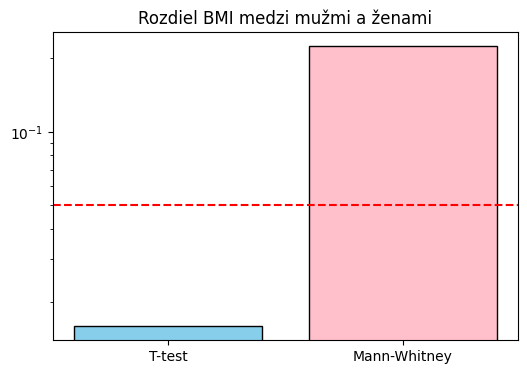

BMI muzi vs zeny
           Test  p-hodnota
0        T-test   0.015972
1  Mann-Whitney   0.223673


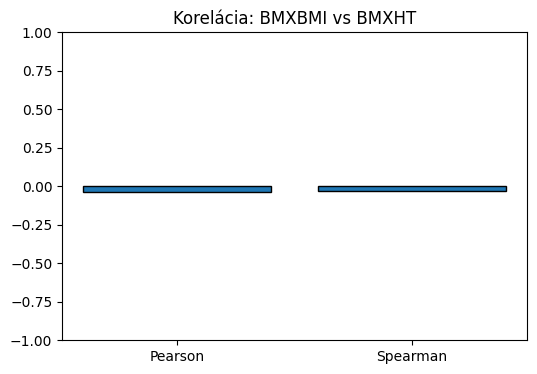


 Korelácia BMI vs BMXHT 
  Typ korelácie   Hodnota
0       Pearson -0.035520
1      Spearman -0.033677


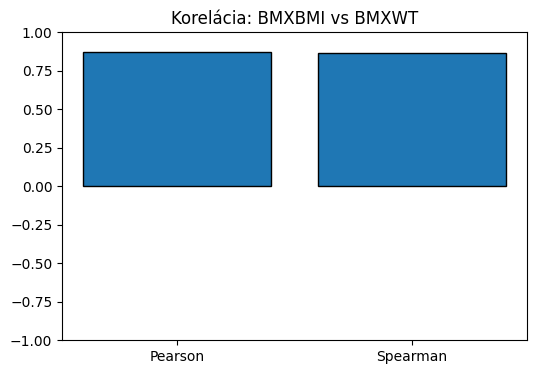


 Korelácia BMI vs BMXWT 
  Typ korelácie   Hodnota
0       Pearson  0.868975
1      Spearman  0.864114


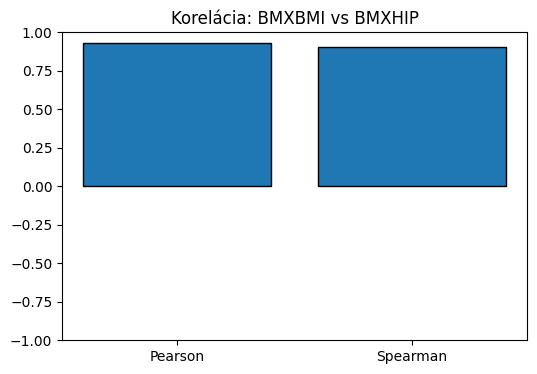


 Korelácia BMI vs BMXHIP 
  Typ korelácie   Hodnota
0       Pearson  0.932637
1      Spearman  0.907613


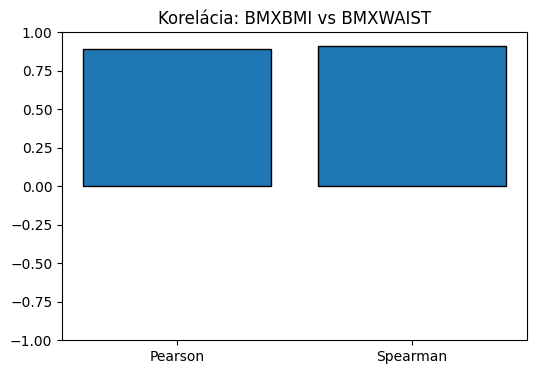


 Korelácia BMI vs BMXWAIST 
  Typ korelácie   Hodnota
0       Pearson  0.891871
1      Spearman  0.909158


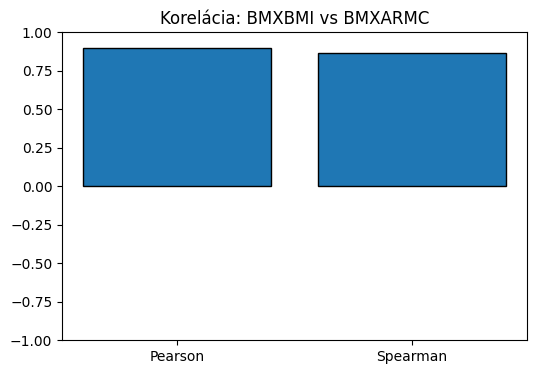


 Korelácia BMI vs BMXARMC 
  Typ korelácie   Hodnota
0       Pearson  0.897488
1      Spearman  0.862364


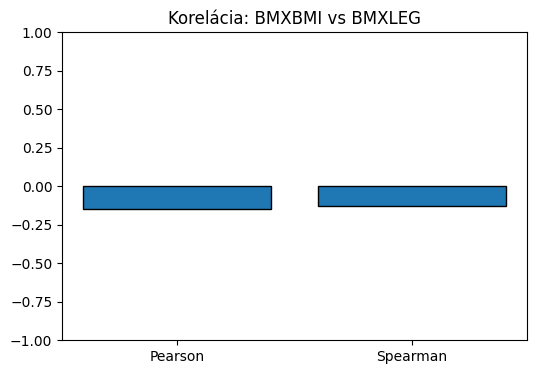


 Korelácia BMI vs BMXLEG 
  Typ korelácie   Hodnota
0       Pearson -0.150038
1      Spearman -0.129489


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os
import re
import sys

sys.path.append(os.path.abspath(".."))
import settings

# nacitanie dat
def load_data():
    bmx = pd.read_sas(settings.bmx_path, format='xport')
    demo = pd.read_sas(settings.demo_path, format='xport')

    df = pd.merge(bmx, demo[['SEQN','RIDAGEYR','RIAGENDR']], on='SEQN', how='left')

    df = df[df['RIDAGEYR'] >= 18].dropna(
        subset=['BMXBMI','BMXWT','BMXHT','BMXHIP','BMXWAIST','BMXARMC','BMXLEG']
    )

    df['gender_label'] = df['RIAGENDR'].map({1: "Men", 2: "Women"})
    return df

data = load_data()

dependent_var = 'BMXBMI'
independent_vars = ['BMXHT','BMXWT','BMXHIP','BMXWAIST','BMXARMC','BMXLEG']

os.makedirs("grafy", exist_ok=True)
os.makedirs("tabulky", exist_ok=True)

# nastavenie farieb pre parametricke a neparametricke testy
colors = {
    "Parametric": "skyblue",
    "Non-Parametric": "pink"
}

x = data[data['gender_label']=="Men"][dependent_var].sample(850).values
y = data[data['gender_label']=="Women"][dependent_var].sample(850).values

t_p = stats.ttest_ind(x, y).pvalue
mw_p = stats.mannwhitneyu(x, y).pvalue

tests = ["T-test", "Mann-Whitney"]
values = [t_p, mw_p]

classification = {
    "T-test": "Parametric",
    "Mann-Whitney": "Non-Parametric"
}

# priradenie farby podla typu testu
bar_colors = [colors[classification[t]] for t in tests]

plt.figure(figsize=(6,4))
plt.bar(tests, values, color=bar_colors, edgecolor='black')

plt.yscale('log')
plt.axhline(0.05, color='red', linestyle='--')
plt.title("Rozdiel BMI medzi mužmi a ženami")

plt.savefig("BMI_gender_test.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# tabuľka + výpis
df_tests = pd.DataFrame({
    "Test": tests,
    "p-hodnota": values
})

print("BMI muzi vs zeny")
print(df_tests)

df_tests.to_csv("BMI_gender_test.csv", index=False)

#korelacie pre kazdu premennu
for var in independent_vars:

    sample = data.sample(300)

    var1 = sample[dependent_var].values
    var2 = sample[var].values

    pearson_r = stats.pearsonr(var1, var2)[0]
    spearman_r = stats.spearmanr(var1, var2)[0]

    # graf
    plt.figure(figsize=(6,4))
    plt.bar(["Pearson","Spearman"], [pearson_r, spearman_r], edgecolor='black')

    plt.ylim(-1,1)
    plt.title(f"Korelácia: {dependent_var} vs {var}")

    filename = re.sub(r'[^\w\-_.]','_', var)

    plt.savefig(f"korelacia_{filename}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # tabuľka + výpis
    df_corr = pd.DataFrame({
        "Typ korelácie": ["Pearson","Spearman"],
        "Hodnota": [pearson_r, spearman_r]
    })

    print(f"\n Korelácia BMI vs {var} ")
    print(df_corr)

    df_corr.to_csv(f"korelacia_{filename}.csv", index=False)

Na základe vykonaných štatistických testov zameraných na polohu, distribúciu a predpoklady dát, môžeme konštatovať nasledujúce zistenia:
    1. Robustnosť výsledku (Senzitivita na výber testu)
        Konzistencia: Všetky testy porovnávajúce polohu (priemer/medián) medzi mužmi a ženami dosiahli extrémnu štatistickú významnosť ($p < 0,001$). 
        Či už ide o klasický Studentov t-test, Welchov t-test pre nerovnomerné rozptyly, alebo neparametrický Mann-Whitneyov test, výsledok zostáva 
        identický.
        Transformácie: Použitie logaritmickej transformácie, Box-Coxovej alebo Yeo-Johnsonovej transformácie nezmenilo interpretáciu výsledkov, čo 
        svedčí o tom, že rozdiel vo výške je v populácii NHANES natoľko dominantný, že nie je závislý od mierky merania.
    2. Analýza predpokladov a metodická správnosť
        Hoci sú p-hodnoty v hlavných testoch extrémne nízke, testy predpokladov naznačujú, že nie všetky metódy sú matematicky rovnocenné:
        Normalita: Shapiro-Wilk a Jarque-Bera testy indikujú, že zatiaľ čo u žien sa dáta blížia k normálnemu rozdeleniu, u mužov je normalita mierne 
        narušená ($p < 0,05$). To uprednostňuje použitie neparametrických testov.
        Homogenita rozptylov: Leveneho, Bartlettov a Fligner-Killeenov test sa zhodujú na porušení predpokladu rovnosti rozptylov ($p < 0,001$). V 
        striktne vedeckom kontexte by mal byť klasický Studentov t-test zamietnutý v prospech Welchovho t-testu alebo Brunner-Munzelovho testu, ktoré 
        sú voči heteroskedasticite odolné.
    3. Vplyv veku a ďalších faktorov
        Vekové skupiny: ANOVA aj Kruskal-Wallisov test potvrdili, že vek je významným faktorom ovplyvňujúcim telesnú výšku ($p < 0,001$), čo naznačuje 
        prítomnosť sekulárneho trendu alebo fyziologických zmien spojených so starnutím naprieč generáciami.Záverečné zhodnotenie z pohľadu "p-
        hackingu"V prípade premennej BMXHT nie je možné hovoriť o úspešnom p-hackingu v zmysle "vytiahnutia" významnosti z nevýznamných dát. Efekt 
        pohlavia na výšku je tak robustný, že akýkoľvek z 13 testov vedie k rovnakému zamietnutiu nulovej hypotézy. Výber "najlepšieho" p-value je v tomto prípade len kozmetickou úpravou, nie vedeckou manipuláciou výsledku.

Pri forme p-hackingu - využívanie alternatívnych testov hypotéz ide o to, že výskmuníci majú voľnú ruku v tom, aký test pre svoje dáta použijú. Skúšajú rôzne typy testov a potom zverejňujú iba výsledky tých testov, ktoré vyšli štatisticky významné. 

**Parametrické testy**
    - testujú parametre rozdelenia ako je napr. priemer a vyžadujú určité predpoklady o dátach (napr. normalita dát, rovnaké rozptyly)
    
**Neparametrické testy**
    - pacujú s poradím dát alebo s početnosťami a na rozdiel od parametrických testov nevyžadujú predpoklady o rozdelení dát 

Použité testy:

    1.Studentov t-test- slúži na porovnanie stredných hodnôt 2 rôznych skupín, ktoré vyžadujú rovnosť rozptylov
    
    2. Welchov t-test - slúži na porovnávanie stredných hodnôt dvoch nezávislých skupín , ktoré nevyžadujú rovnosť rozptylov
    
    3. Mann-Whitney test - slúži na porovnanie dvoch nezávislých skupín, porovnáva rozdelenia alebo či má jedna vzorka tendenciu mať vyššie hodnoty
    
    4. Kolmogorovov - Smirnovov test - slúži na porovnanie distribúcií, je to neparametrický test
    
    5. Brunner-Munzel - rovnako ako Mann-Whitney test porovnáva rozdelenia dvoch skupín, ale s tým rozdielom, že Bunner-Munzel test nevyžaduje predpoklad rovnakých rozptýlení
    
    6. Median test - neparametrický test, ktorý porovnáva, či sa mediány dvoch alebo viacerých nezávislých skupín významne líšia
    
    7. Shapiro-Wilk - test, ktorý sa používa na zistenie, či dáta sú normálne rozdelené alebo nie
    
    8. Jarque–Bera - štatistický test dobrej zhody - testuje či sa šikmosť a špicatosť dát zhodujú s tými, ktoré má normálne rozdelenie
    
    9. Levene test - štatistická metóda na overenie predpokladu homogenity (rovnosti) rozptylov medzi dvoma alebo viacerými skupinami dát - nepredpokladá normalitu
    
    10. Bartlett test - rovnako ale Levenov test sa používa na testovanie rovnosti rozptylov - predpokladá normalitu
    
    11. Fligner-Killeen - neparametrický test na overenie rovnosti rozptylov, nepredpokladá normalitu a je robustnejší
    
    12. Kruskal-Wallis - neparametrická štatistická metóda na porovnanie troch alebo viacerých nezávislých skupín, testuje odlišnosť mediánov
    
    13. ANOVA - Analýza rozptylu - slúži na to aby sme zistili, či sa priemery viacerých skupín štatisticky významne líšia